# Proyecto de Grafos - Estilo de Juego: Francia

## Objetivo
Construir un grafo que represente como circulo el balon entre los jugadores de
Francia durante la fase de grupos del Mundial Qatar 2022, e interpretar el
estilo de juego del equipo a partir de la estructura de ese grafo.

In [7]:
import pandas as pd

# 1) Cargamos el csv de Francia
df = pd.read_csv("pases_francia.csv")

# 2) Nos quedamos solo con los partidos de fase de grupos
df_tunisia = df[df["oponente"] == "Tunisia"]
df_denmark = df[df["oponente"] == "Denmark"]
df_australia = df[df["oponente"] == "Australia"]


# 3) Vistazo rápido para confirmar que quedó bien
print("Filas totales:", len(df))
print("Filas para partido uno, dos y tres:", len(df_tunisia), len(df_denmark), len(df_australia))
print(df_tunisia["oponente"].unique())  # deberían salir los 3 rivales de la fase de grupos
print(df_denmark["oponente"].unique())  # deberían salir los 3 rivales de la fase de grupos
print(df_australia["oponente"].unique())  # deberían salir los 3 rivales de la fase de grupos



Filas totales: 3926
Filas para partido uno, dos y tres: 661 540 763
<StringArray>
['Tunisia']
Length: 1, dtype: str
<StringArray>
['Denmark']
Length: 1, dtype: str
<StringArray>
['Australia']
Length: 1, dtype: str


## Importación de la librería networkx

In [8]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Construcción del grafo dirigido

In [34]:
import networkx as nx

# 1) Filtramos solo los pases completados
df_completos = df_tunisia[df_tunisia["resultado"] == "Complete"]
df_completos1 = df_denmark[df_denmark["resultado"] == "Complete"]
df_completos2 = df_australia[df_australia["resultado"] == "Complete"]

# 2) Creamos el grafo dirigido
G1 = nx.DiGraph()
G2 = nx.DiGraph()
G3 = nx.DiGraph()


# 3) Recorremos cada pase y agregamos la conexión
for _, fila in df_completos.iterrows():
    emisor = fila["jugador_nombre"]
    receptor = fila["receptor_nombre"]
    G1.add_edge(emisor, receptor)
    

for _, fila in  df_completos1.iterrows():
    emisor = fila["jugador_nombre"]
    receptor = fila["receptor_nombre"]
    G2.add_edge(emisor,receptor)


for _, fila in df_completos2.iterrows():
    emisor = fila["jugador_nombre"]
    receptor = fila["receptor_nombre"]
    G3.add_edge(emisor,receptor)

# 4) Vistazo rápido para confirmar que el grafo se armó bien
print('\n')
print("Numero de pases (aristas):", G1.number_of_edges())
print("Numero de jugadores (nodos):", G1.number_of_nodes())
print('\n')
print("Ejemplo de conexiones:")
for emisor, receptor in list(G1.edges())[:5]:

    print(f"  {emisor} -> {receptor}")
print('\n')
print("Numero de jugadores (nodos):", G2.number_of_nodes())
print("Numero de pases (aristas):", G2.number_of_edges())
print('\n')
print("Ejemplo de conexiones:")
for emisor, receptor in list(G2.edges())[:5]:
    print(f"  {emisor} -> {receptor}")

print('\n')
print("Numero de pases (aristas):", G3.number_of_edges())
print("Numero de jugadores (nodos):", G3.number_of_nodes())
print('\n')
for emisor, receptor in list(G3.edges())[:5]:
    print(f"  {emisor} -> {receptor}")

print("Ejemplo de conexiones:")



Numero de pases (aristas): 150
Numero de jugadores (nodos): 16


Ejemplo de conexiones:
  Steve Mandanda -> Raphaël Varane
  Steve Mandanda -> Eduardo Camavinga
  Steve Mandanda -> Ibrahima Konaté
  Steve Mandanda -> Jordan Veretout
  Steve Mandanda -> Aurélien Djani Tchouaméni


Numero de jugadores (nodos): 15
Numero de pases (aristas): 118


Ejemplo de conexiones:
  Ousmane Dembélé -> Jules Koundé
  Ousmane Dembélé -> Adrien Rabiot
  Ousmane Dembélé -> Antoine Griezmann
  Ousmane Dembélé -> Olivier Giroud
  Ousmane Dembélé -> Aurélien Djani Tchouaméni


Numero de pases (aristas): 127
Numero de jugadores (nodos): 15


  Olivier Giroud -> Aurélien Djani Tchouaméni
  Olivier Giroud -> Antoine Griezmann
  Olivier Giroud -> Theo Bernard François Hernández
  Olivier Giroud -> Kylian Mbappé Lottin
  Aurélien Djani Tchouaméni -> Adrien Rabiot
Ejemplo de conexiones:


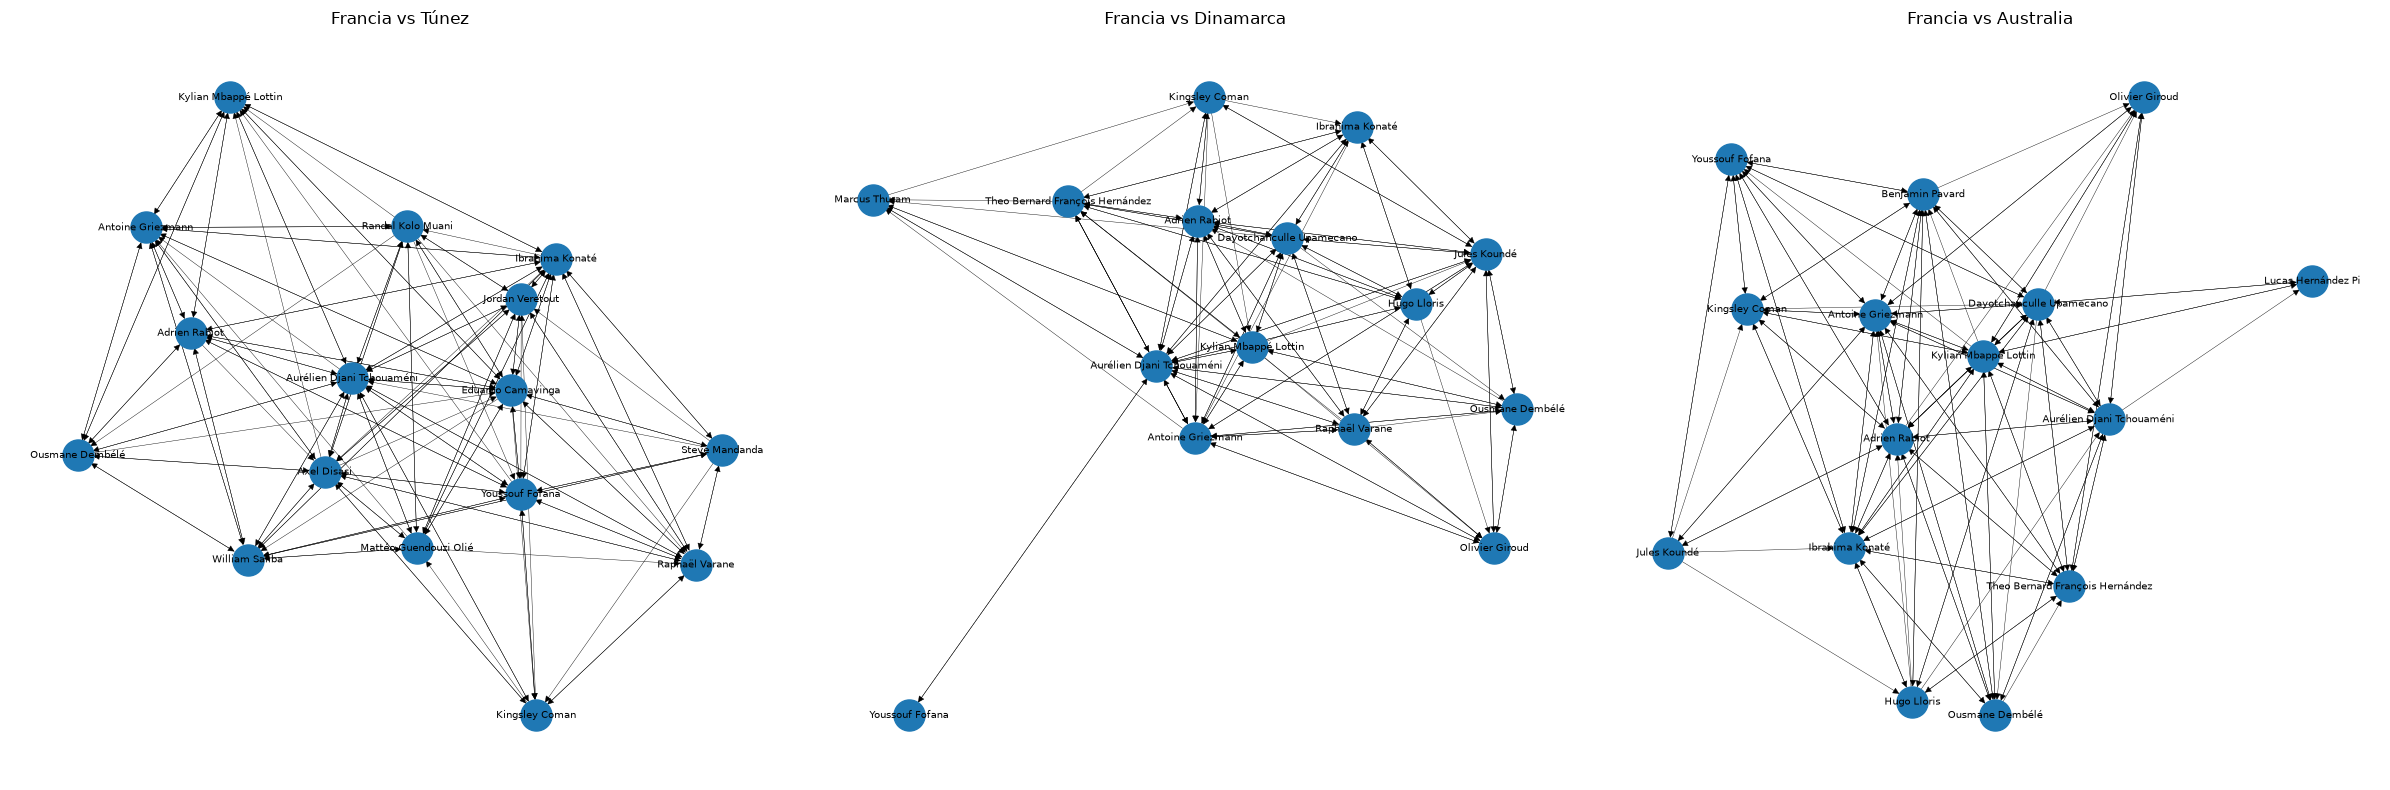

In [35]:
from matplotlib import pyplot as plt
import networkx as nx

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

grafos = [
    (G1, "Francia vs Túnez"),
    (G2, "Francia vs Dinamarca"),
    (G3, "Francia vs Australia")
]

for ax, (G, titulo) in zip(axes, grafos):
    pos = nx.spring_layout(G, seed=42)

    nx.draw(
        G,
        pos,
        ax=ax,
        with_labels=True,
        node_size=500,
        font_size=7,
        width=0.3,
        arrows=True
    )

    ax.set_title(titulo)
    ax.axis("off")

plt.tight_layout()
plt.show()